# Loading and plotting validation tracks from Matthew Preistley

Workflow:

1. **Define the region** we want storms from, and a larger **tracking domain** around it.
2. **Prepare the input field**: ERA5 850 hPa relative vorticity (`vo`), 6-hourly, 0.25°.
3. **Run the Hodges tracker** (`pystormtracker.HodgesTracker`) on the whole tracking domain.
4. **Post-process** the raw tracks: keep only real, mobile, long-lived cyclones (TRACK's RSPLICE filter) that affect the region.
5. **Plot** raw vs. kept tracks.
6. **Save** the filtered tracks and a per-track summary table.
7. **Sample other ERA5 fields** (t2m, msl, 10 m wind) along the kept tracks.

Helper functions live in `stormtracker.py`.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import pystormtracker as pst

import importlib
import stormtracker as st
importlib.reload(st)  # pick up edits in stormtracker.py without restarting the kernel

<module 'stormtracker' from '/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/validation_tracks/stormtracker.py'>

## 1. Region of interest and tracking domain

Boxes are given as `(lon_min, lon_max, lat_min, lat_max)` in degrees, longitudes in −180…180.

* **`REGION`** — where we want storms: the North Atlantic storm track and Northern Europe
  (60°W–30°E, 40°N–75°N). This box is only used *after* tracking, to select tracks.
* **`DOMAIN`** — the area actually given to the tracker. It is **larger than the region** on purpose:
  * the spatial taper (`taper_points`) and the regional DCT band-pass filter distort the field near the
    domain edges, giving spurious or displaced vorticity maxima there;
  * a storm that forms west of the region (e.g. off Newfoundland) and moves in should be tracked from its
    real genesis, not from where it first crosses the box. Otherwise lifetimes, genesis positions and
    peak intensities are biased.

So we track in the big box and select tracks that affect the small box, but keep each selected track
**whole** (including the parts outside the region) so its full life cycle is available.

> With the current file the buffer is 20° to the west, 10° to the east and south, but only 5° to the
> north (the data stop at 80°N). If you download more data, a domain like `(-100, 60, 20, 90)` gives
> a more comfortable buffer.

In [40]:
#Importing the data from the file
REGION = (-80, 20, 30, 80)   # smaller region for tracking, limited by the domain, 10 deg smaller
DOMAIN = (-90, 30, 20, 90)   # tracking domain (region + buffer), limited by the downloaded data


tracks_from_matty = st.load_tracks('/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/validation_tracks/ERA5_19992000_TRACKS_FILTERED_pos.addmslp')
tracks_from_matty = tracks_from_matty.assign_coords(lon=st.wrap_lon(tracks_from_matty.lon))
summary = st.track_summary(tracks_from_matty)

long_tracks = summary.track_id[summary.n_points >= 8]
#storm7 = st.select_track(tracks_from_matty, 1)

KeyError: "No variable named 'lon'. Variables on the dataset include ['step', 'lat', 'vorticity', 'mslp_lon', 'mslp_lat', 'mslp', 'track_id']"

<GeoAxes: title={'center': 'Tracks'}>

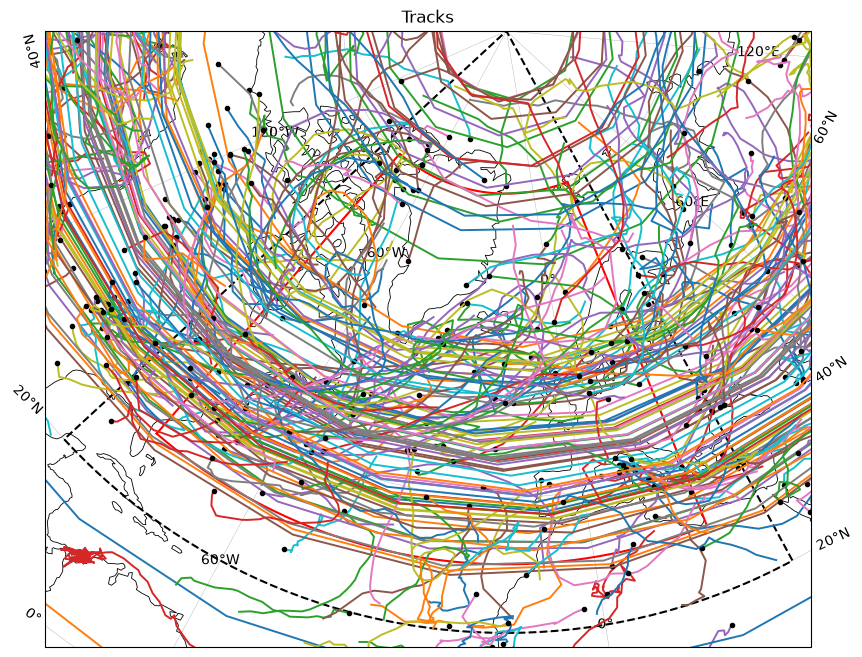

In [41]:
st.plot_regional_tracks(tracks_from_matty, region=REGION, domain=DOMAIN, object = False)

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
#(west, east, south, north) 
REGION = (-80, 20, 30, 80)   # lon_min, lon_max, lat_min, lat_max
DOMAIN = (-90, 30, 20, 90)


def in_region(ds, region):
    """Boolean mask over `obs`: is the track point inside the region?"""
    lon_min, lon_max, lat_min, lat_max = region
    lon = st.wrap_lon(ds.lon)
    return (lon >= lon_min) & (lon <= lon_max) & (ds.lat >= lat_min) & (ds.lat <= lat_max)


def filter_tracks_by_region(ds, region, min_points=2):
    """Keep only tracks with at least `min_points` points inside `region`.

    Whole tracks are kept (including their points outside the region).
    """
    inside = in_region(ds, region)
    counts = inside.groupby("track_id").sum()
    keep_ids = counts.track_id.values[counts.values >= min_points]
    idx = np.where(np.isin(ds.track_id.values, keep_ids))[0]
    return ds.isel(obs=idx)


def plot_tracks(ds, region=REGION, domain=DOMAIN, ax=None, date='Dec 1999'):
    """Plot each track as a line, with the region and domain boxes."""
    if ax is None:
        fig = plt.figure(figsize=(10, 7))
        ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([domain[0]-20, domain[1]+20, domain[2]-10, domain[3]], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    lon_all = st.wrap_lon(ds.lon).values
    lat_all = ds.lat.values
    ids = ds.track_id.values
    for tid in np.unique(ids):
        m = ids == tid
        ax.plot(lon_all[m], lat_all[m], lw=1, alpha=0.8, transform=ccrs.PlateCarree())
        ax.plot(lon_all[m][0], lat_all[m][0], "o", color="C1", markersize=4, transform=ccrs.PlateCarree())

    # region box (red) and domain box (grey dashed)
    for box, style in ((region, dict(color="red", lw=1.5)),
                       (domain, dict(color="grey", lw=1, ls="--"))):
        x0, x1, y0, y1 = box
        ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0],
                transform=ccrs.PlateCarree(), **style)

    ax.set_title(f"{np.unique(ids).size} tracks in region {region} in {date}")
    return ax

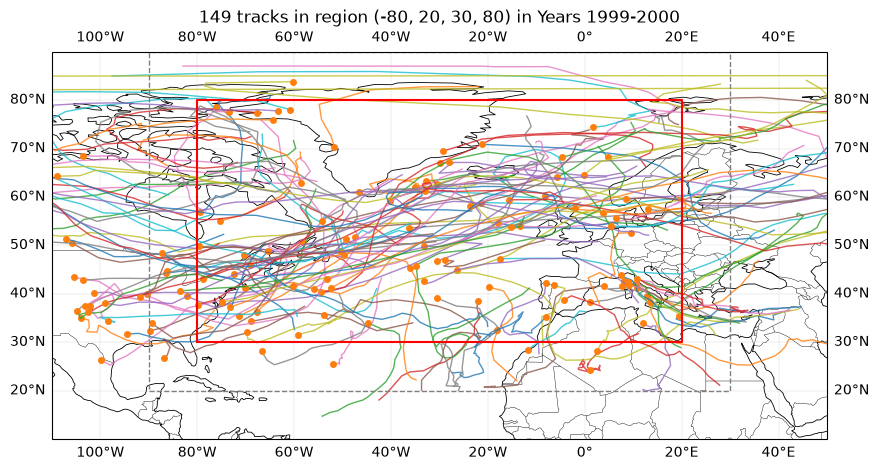

In [56]:
ds = st.load_tracks('/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/validation_tracks/ERA5_19992000_TRACKS_FILTERED_pos.addmslp')
sel = filter_tracks_by_region(ds, REGION, min_points=2)
plot_tracks(sel, date = 'Years 1999-2000')
plt.show()


## 2. Prepare the tracking field

`st.prepare_tracking_field` makes a clean `(time, latitude, longitude)` field:

* selects the **850 hPa** level — the standard level for vorticity-based cyclone tracking
  (Hoskins & Hodges 2002). It is less noisy than the surface and less affected by orography than MSLP;
* converts longitudes to −180…180 and sorts them, so a domain crossing 0° is one continuous box
  (ERA5 downloads are sometimes 0…360);
* cuts out `DOMAIN` and drops the extra ERA5 coordinates (`expver`, `number`).

In [4]:
vo = st.prepare_tracking_field(INPUT_FILE, variable='vo', level=850, domain=DOMAIN)
time_name = 'valid_time' if 'valid_time' in vo.coords else 'time'
TIME_RANGE = (vo[time_name].values[0], vo[time_name].values[-1])
vo

NameError: name 'INPUT_FILE' is not defined

## 3. Run the Hodges tracker

Parameter choices:

| parameter | value | why |
|---|---|---|
| `lmin, lmax` | 5, 42 | Band-pass filter keeping wavenumbers T5–T42 (Hoskins & Hodges 2002). Removes the large-scale background (T0–4) and small-scale noise, leaving synoptic-scale systems. Because the domain is regional, pystormtracker uses a **DCT filter** with "equivalent" wavenumbers instead of spherical harmonics. The filter is also why we pass 0.25° data without regridding: the smoothing removes the fine-scale noise. |
| `taper_points` | 10 | Smoothly tapers the field to zero over the outermost 10 grid points (2.5° at 0.25°), which reduces edge artefacts from the DCT. |
| `object_threshold` | 1e-5 s⁻¹ | A feature must reach at least 1×10⁻⁵ s⁻¹ in the **filtered** field (standard for T42 vo850). |
| `min_object_grid_points` | 18 | The object above the threshold must cover ≥18 grid points; removes tiny noisy maxima. |
| `exclude_boundary_extrema` | True | Ignore maxima that sit on the domain edge. |
| `dmax` | default zones (6.5°/step north of 20°N) | Maximum displacement between two time steps. 6.5° per 6 h ≈ 120 km/h, fast enough for the fastest storms. The `dmax` argument is only used with `use_dmax_zones=False`. |
| `min_track_points` | 4 | Deliberately **low**: the tracker only removes the very shortest fragments. The real lifetime/displacement filter (RSPLICE) is applied in the post-processing (step 4), where we can see what is removed. |

In [4]:
# raw_tracks = st.hodges_tracker(
#     vo,
#     output_file_name=OUT_NAME + '_raw',   # raw tracks are saved too, so the tracker need not be re-run
#     track_variable='vo',
#     lmin=5, lmax=42,
#     taper_points=10,
#     object_threshold=1e-5,
#     min_object_grid_points=18,
#     exclude_boundary_extrema=True,
#     min_track_points=4,
# )
# print(f'{len(raw_tracks)} raw tracks, {len(raw_tracks.lats)} track points')

In [ ]:
# to skip the tracking later, reload the raw tracks instead:
file_path ='/Users/asgerthormann/Documents/uni/master/master_code/master_thesis/validation_tracks/'
file_name = 'ERA5_20132014_TRACKS_FILTERED_pos.addmslp_NEW.npy'
raw_tracks = np.load(file_path + file_name, allow_pickle=True)

## 4. Post-processing

The raw output contains many features that are not cyclones affecting the region: short-lived noise,
stationary (e.g. orographic / lee) vorticity maxima, and tracks along the domain edges.
`st.postprocess_tracks` computes a per-track summary and applies these criteria.
Each one becomes a column `ok_<name>` (True = passes); a track is kept only if it passes **all**:

1. **`ok_region`** — the track must affect the region. `region_criterion` sets how:
   * `"passes"`: at least `min_points_in_region` points inside `REGION`. We use 2 (≥ 6 h inside),
     so tracks that only clip a corner of the box are not counted. Good for "storms that hit the region".
   * `"genesis"`: the storm forms inside the region (for genesis climatologies).
   * `"peak"`: the storm reaches its maximum intensity inside the region.
2. **`ok_rsplice`** — TRACK's **RSPLICE** lifetime and displacement filter
   (`pystormtracker.hodges.rsplice.filter_rsplice`), the standard post-processing step of the Hodges
   TRACK software. It replaces separate lifetime and distance thresholds and keeps a track only if
   * it has at least **8 points** (`rsplice_min_points`, = 48 h at 6 h). Missing frames inside a track
     also count, which is why the data time step (`rsplice_cadence = 6 h`) is passed. This removes
     short-lived noise and features that the tracker linked by chance;
   * its **endpoint displacement** (great-circle distance genesis → lysis) is at least **10°**
     (`rsplice_distance_degrees`, ≈ 1110 km). This removes quasi-stationary features: lee vorticity
     near Greenland/Norway, thermal lows, heat lows over land. `rsplice_distance_mode="travel"` uses
     the total path length instead.

   The summary gets `rsplice_points`, `rsplice_displacement_deg` and `ok_rsplice`, so you can see how
   close each track was to the thresholds.
3. **`ok_edge`** — at most 25 % of the track points may be within 5° of the edge of `DOMAIN`.
   Near the edges the taper and DCT filter create artificial maxima; tracks running along the boundary
   (e.g. zig-zagging along 80°N) are artefacts.
4. **`ok_peak`** (optional, `min_peak`) — minimum peak intensity, e.g. 3e-5 s⁻¹ if you only want
   stronger storms. Off by default because the object threshold already requires 1e-5 s⁻¹.
5. **`ok_time`** (optional, `drop_time_truncated=True`) — removes tracks that already exist at the
   first time step or still exist at the last one; their genesis/lysis and lifetime are unknown.
   The summary always contains `starts_at_first_frame` / `ends_at_last_frame`, so you can see them.
   For long runs (months/years) you normally keep them off and instead add a few days of spin-up
   before and after the period you analyse.

Filtering keeps **whole tracks**; points outside the region are not cut off.

In [ ]:
tracks, summary, points = st.postprocess_tracks(
    raw_tracks,
    region=REGION,
    domain=DOMAIN,
    time_range=TIME_RANGE,
    region_criterion='passes',
    min_points_in_region=2,
    rsplice_min_points=8,                     # >= 48 h at 6 h
    rsplice_max_points=None,
    rsplice_distance_degrees=10.0,            # genesis -> lysis >= 10 degrees
    rsplice_distance_mode='endpoint',
    rsplice_cadence=np.timedelta64(6, 'h'),   # ERA5 time step
    edge_buffer_deg=5,
    max_frac_at_edge=0.25,
    min_peak=None,
    drop_time_truncated=False,
)

st.filter_report(summary)

raw tracks: 6605, kept: 1270


,removed_by_this_criterion,removed_only_by_this_criterion
rsplice,5000,2726
region,2209,26
edge,2141,201
peak,0,0
time,0,0


`removed_by_this_criterion` counts every track that fails a test; `removed_only_by_this_criterion`
counts tracks that fail **only** that test, i.e. that would be kept if the criterion were relaxed.
That column tells you which thresholds actually matter.

The distributions below help to judge whether the thresholds (dashed lines) are sensible.

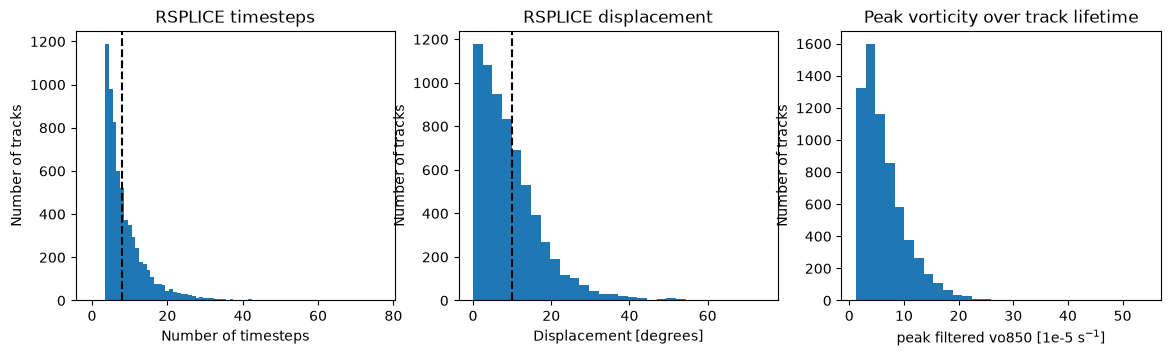

In [16]:
scale = 'linear'
fig, axs = plt.subplots(1, 3, figsize=(14, 3.5))
axs[0].set_xscale(scale)
axs[0].set_yscale(scale)
axs[0].hist(summary['rsplice_points'], bins=np.arange(0, summary['rsplice_points'].max() + 2) - 0.5)
axs[0].axvline(8, color='k', ls='--')
axs[0].set_xlabel('Number of timesteps')
axs[0].set_title('RSPLICE timesteps')


axs[1].set_xscale(scale)
axs[1].set_yscale(scale)
axs[1].hist(summary['rsplice_displacement_deg'], bins=30)
axs[1].axvline(10, color='k', ls='--')
axs[1].set_xlabel('Displacement [degrees]')
axs[1].set_title('RSPLICE displacement')

axs[2].set_xscale(scale)
axs[2].set_yscale(scale)
axs[2].hist(summary['vo_peak'] * 1e5, bins=30)
axs[2].set_xlabel('peak filtered vo850 [1e-5 s$^{-1}$]')
axs[2].set_title('Peak vorticity over track lifetime')
for ax in axs: ax.set_ylabel('Number of tracks')

In [8]:
# kept tracks
summary[summary['keep']][['track_id', 'start_time', 'end_time', 'duration_h', 'n_in_region',
                          'rsplice_points', 'rsplice_displacement_deg', 'path_km',
                          'vo_peak', 'time_peak', 'lat_peak', 'lon_peak',
                          'starts_at_first_frame', 'ends_at_last_frame']]

,track_id,start_time,end_time,duration_h,n_in_region,rsplice_points,rsplice_displacement_deg,path_km,vo_peak,time_peak,lat_peak,lon_peak,starts_at_first_frame,ends_at_last_frame
1,3,1990-01-15 00:00:00,1990-01-18 12:00:00,84.0,15,15,11.884977,2835.615513,0.000137,1990-01-15 00:00:00,59.75,-36.75,False,False
5,9,1990-01-16 06:00:00,1990-01-18 12:00:00,54.0,6,10,14.019227,3226.895735,0.000070,1990-01-18 12:00:00,71.50,21.50,False,False
9,15,1990-01-07 18:00:00,1990-01-10 12:00:00,66.0,12,12,30.057814,3554.383619,0.000368,1990-01-08 06:00:00,56.25,-31.25,False,False
12,22,1990-01-01 00:00:00,1990-01-05 00:00:00,96.0,17,17,26.292481,4104.029010,0.000104,1990-01-02 18:00:00,41.00,-11.50,True,False
45,110,1990-01-04 06:00:00,1990-01-08 06:00:00,96.0,10,17,23.050946,2834.727458,0.000091,1990-01-05 18:00:00,32.50,14.75,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6576,19247,1990-12-25 18:00:00,1990-12-27 18:00:00,48.0,9,9,12.129518,2252.651874,0.000067,1990-12-25 18:00:00,48.25,0.50,False,False
6578,19249,1990-12-19 00:00:00,1990-12-21 12:00:00,60.0,5,11,12.057117,1768.316525,0.000055,1990-12-20 18:00:00,32.25,8.75,False,False
6595,19277,1990-12-25 00:00:00,1990-12-27 18:00:00,66.0,6,12,11.514219,3787.217181,0.000168,1990-12-25 00:00:00,76.50,-11.75,False,False
6602,19311,1990-12-22 12:00:00,1990-12-24 12:00:00,48.0,7,9,11.847062,3511.947751,0.000251,1990-12-24 12:00:00,74.50,-14.25,False,False


## 5. Plot

Red box: `REGION`. Dashed box: tracking `DOMAIN`. Coloured: kept tracks (black dot = genesis).
Grey: tracks removed by the post-processing.

/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


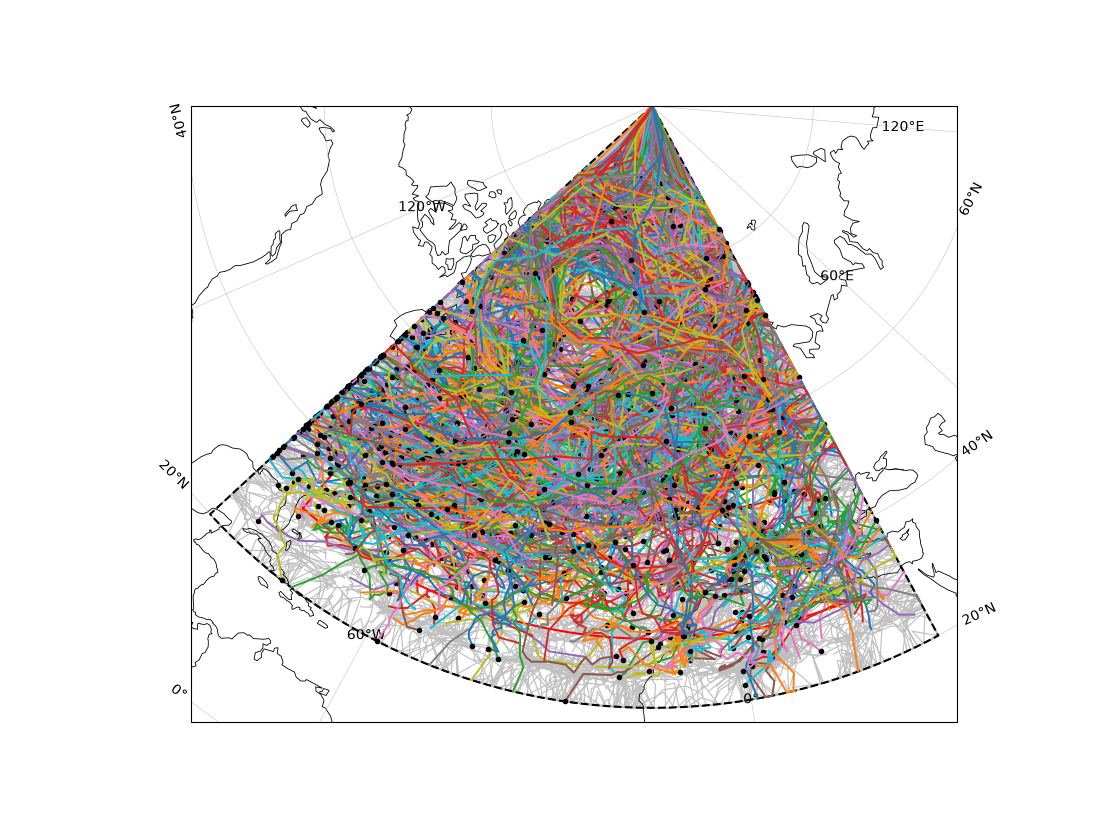

In [13]:
st.plot_regional_tracks(raw_tracks, REGION, DOMAIN, summary=summary,
                        title=f'{len(tracks)} of {len(raw_tracks)} tracks kept, '
                              f'{pd.Timestamp(TIME_RANGE[0]):%Y-%m-%d} to {pd.Timestamp(TIME_RANGE[1]):%Y-%m-%d}');

## 6. Save

* `*_filtered.trackjson` — the kept tracks (load again with `pst.load_tracks`).
* `*_summary.csv` — one row per **raw** track with all criteria, so the filtering can be reproduced
  or changed later without re-running the tracker.

In [10]:
tracks.write(OUT_NAME + '_filtered.trackjson')
summary.to_csv(OUT_NAME + '_summary.csv', index=False)

## 7. Sample ERA5 fields along the kept tracks

`st.track_statistics` samples fields around every track point (within `radius_km`) and summarises each track:
minimum / maximum 2 m temperature, minimum MSLP, maximum and mean 10 m wind speed within 500 km.
Wind speed is computed on the grid from `u10`, `v10` before sampling.

Note: the single-level file only reaches **70°N**, so points north of that give NaN (a warning is shown).
Download that file for the same area as `DOMAIN` to avoid this.

In [11]:
track_points, track_summary = st.track_statistics(
    tracks, SAMPLE_FILE, radius_km=500, strict_time=False,
)
track_summary

/Users/asgerthormann/Documents/uni/master/master_code/master_thesis/PyStormTracker/stormtracker.py:195: UserWarning: Track times not fully covered by dataset: tracks span 1990-01-01 00:00:00 -> 1990-12-31 18:00:00, dataset spans 2004-02-17 00:00:00 -> 2004-02-21 18:00:00; 0.0% of track points inside the dataset range, 0.0% with an exact time match.
  warnings.warn("Track times not fully covered by dataset: " + msg)
/Users/asgerthormann/Documents/uni/master/master_code/master_thesis/PyStormTracker/stormtracker.py:302: UserWarning: NaNs in sampled fields (check time/space coverage):
t_min      0.172774
t_max      0.172774
msl_min    0.172774
ws_max     0.172774
ws_mean    0.172774
  warnings.warn("NaNs in sampled fields (check time/space coverage):\n"


,track_id,t_min,t_max,msl_min,ws_max,ws_mean,vo_max,n_points,start_time,end_time,duration_h,lat_genesis,lon_genesis,lat_lysis,lon_lysis,time_of_vo_max
0,3,247.951355,282.873230,98324.50,20.769442,11.697545,0.000137,15,1990-01-15 00:00:00,1990-01-18 12:00:00,84.0,59.75,-36.75,68.50,-18.00,1990-01-15 00:00:00
1,9,257.775574,277.675964,100823.50,13.699553,7.538940,0.000070,10,1990-01-16 06:00:00,1990-01-18 12:00:00,54.0,84.00,-13.75,71.50,21.50,1990-01-18 12:00:00
2,15,253.047058,288.619324,99126.25,20.769442,10.547244,0.000368,12,1990-01-07 18:00:00,1990-01-10 12:00:00,66.0,47.50,-41.00,73.50,-6.75,1990-01-08 06:00:00
3,22,270.451355,292.945496,101169.25,13.645073,5.708898,0.000104,17,1990-01-01 00:00:00,1990-01-05 00:00:00,96.0,37.75,-40.25,44.75,-6.25,1990-01-02 18:00:00
4,110,272.961121,289.972839,101564.75,8.881927,3.588683,0.000091,17,1990-01-04 06:00:00,1990-01-08 06:00:00,96.0,30.75,3.25,24.25,28.25,1990-01-05 18:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,19247,259.756042,287.775574,101784.00,10.953661,3.036364,0.000067,9,1990-12-25 18:00:00,1990-12-27 18:00:00,48.0,48.25,0.50,41.25,14.50,1990-12-25 18:00:00
1266,19249,272.961121,287.127136,101871.25,8.413741,2.734188,0.000055,11,1990-12-19 00:00:00,1990-12-21 12:00:00,60.0,24.25,-0.50,32.75,9.25,1990-12-20 18:00:00
1267,19277,248.754089,273.248230,98355.50,20.373993,8.404490,0.000168,12,1990-12-25 00:00:00,1990-12-27 18:00:00,66.0,76.50,-11.75,72.75,-54.00,1990-12-25 00:00:00
1268,19311,256.783386,278.982605,100823.50,13.699553,4.785196,0.000251,9,1990-12-22 12:00:00,1990-12-24 12:00:00,48.0,73.75,30.00,74.50,-14.25,1990-12-24 12:00:00


In [12]:
track_points.head()

,track_id,time,lat,lon,t_min,t_max,msl_min,ws_max,ws_mean,vo,major_km,minor_km,gridcell_area_km2,fitted_area_km2
0,3,1990-01-15 00:00:00,59.75,-36.75,247.951355,281.845886,98324.50,20.769442,12.672029,0.000137,2927.064947,1244.039438,6.176888e+06,1.143975e+07
1,3,1990-01-15 06:00:00,63.00,-26.75,269.799011,282.795105,99278.75,20.457779,13.248365,0.000089,2868.608843,1389.983707,6.040142e+06,1.252653e+07
2,3,1990-01-15 12:00:00,60.25,-33.00,269.904480,282.480652,98776.25,20.769442,14.345578,0.000129,2643.568531,2014.897011,6.987701e+06,1.673375e+07
3,3,1990-01-15 18:00:00,62.00,-27.50,273.863464,282.873230,99299.50,20.769442,14.071048,0.000118,1535.895413,1475.095374,4.555588e+06,7.117568e+06
4,3,1990-01-16 00:00:00,63.25,-28.50,265.367371,282.670105,99109.00,20.557993,13.430525,0.000118,1466.986166,1051.710034,3.113830e+06,4.846988e+06


## Notes for longer periods

* Download the tracking field with a few days extra before and after the period you analyse (spin-up),
  and select tracks by time afterwards. Then the `starts_at_first_frame` / `ends_at_last_frame`
  flags only affect the extra days.
* For years of 0.25° data, run the tracker per season/month with some overlap, or on a
  coarser grid (e.g. `vo.coarsen(latitude=2, longitude=2, boundary='trim').mean()`, still well
  above T42 resolution) to save time and memory.
* Check sensitivity: re-run `st.postprocess_tracks` with other thresholds (e.g. `rsplice_min_points=4`, `rsplice_distance_degrees=5`) —
  it only uses `raw_tracks`, so the tracker need not be re-run.